# Football IQ — Data Understanding & Data Preparation


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

RAW = "data/"
PROCESSED = "data/processed/"
import os
os.makedirs(PROCESSED, exist_ok=True)


## 1. Match-Level Data (2021-22, 2022-23, 2023-24)


In [99]:
match_files = {
    "2021-2022": RAW + "Premier-league_2021-2022.csv",
    "2022-2023": RAW + "Premier-league_2022-2023.csv",
    "2023-2024": RAW + "Premier-league_2023-2024.csv",
}

match_dfs = []
for season, path in match_files.items():
    df = pd.read_csv(path)
    df['season'] = season
    match_dfs.append(df)

matches = pd.concat(match_dfs, ignore_index=True)
print(matches.shape)
matches.head()


(840, 39)


,Wk,Day,Date,Time,Home,xG_x,xG_y,Away,Attendance,Venue,Referee,game_id,Score_x,Score_y,Fouls_x,Corners_x,Crosses_x,Touches_x,Tackles_x,Interceptions_x,Aerials Won_x,Clearances_x,Offsides_x,Goal Kicks_x,Throw Ins_x,Long Balls_x,Fouls_y,Corners_y,Crosses_y,Touches_y,Tackles_y,Interceptions_y,Aerials Won_y,Clearances_y,Offsides_y,Goal Kicks_y,Throw Ins_y,Long Balls_y,season
0,1.0,Fri,2021-08-13,20:00,Brentford,1.2,1.3,Arsenal,16479.0,Brentford Community Stadium,Michael Oliver,0,2,0,12.0,2.0,9.0,455.0,20.0,9.0,17.0,22.0,1.0,16.0,19.0,83.0,8.0,5.0,22.0,742.0,9.0,7.0,20.0,15.0,1.0,8.0,26.0,61.0,2021-2022
1,1.0,Sat,2021-08-14,12:30,Manchester Utd,1.5,0.5,Leeds United,72732.0,Old Trafford,Paul Tierney,1,5,1,11.0,5.0,11.0,568.0,6.0,8.0,11.0,16.0,2.0,12.0,27.0,57.0,9.0,4.0,14.0,584.0,23.0,14.0,9.0,12.0,3.0,10.0,17.0,70.0,2021-2022
2,1.0,Sat,2021-08-14,15:00,Leicester City,0.5,1.3,Wolves,31983.0,King Power Stadium,Craig Pawson,2,1,0,6.0,5.0,7.0,752.0,15.0,11.0,10.0,17.0,5.0,8.0,26.0,40.0,10.0,4.0,16.0,608.0,20.0,13.0,12.0,16.0,4.0,3.0,21.0,68.0,2021-2022
3,1.0,Sat,2021-08-14,15:00,Burnley,1.5,1.0,Brighton,16910.0,Turf Moor,David Coote,3,1,2,10.0,7.0,36.0,428.0,16.0,10.0,26.0,14.0,1.0,4.0,24.0,68.0,7.0,6.0,14.0,670.0,16.0,6.0,20.0,30.0,0.0,8.0,24.0,87.0,2021-2022
4,1.0,Sat,2021-08-14,15:00,Chelsea,0.7,0.2,Crystal Palace,38965.0,Stamford Bridge,Jonathan Moss,4,3,0,15.0,5.0,22.0,802.0,21.0,11.0,6.0,9.0,0.0,5.0,17.0,64.0,11.0,2.0,5.0,547.0,11.0,9.0,14.0,26.0,1.0,9.0,14.0,43.0,2021-2022


In [100]:
# quick structural check
matches.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 39 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Wk               840 non-null    float64
 1   Day              840 non-null    object 
 2   Date             840 non-null    object 
 3   Time             840 non-null    object 
 4   Home             840 non-null    object 
 5   xG_x             840 non-null    float64
 6   xG_y             840 non-null    float64
 7   Away             840 non-null    object 
 8   Attendance       834 non-null    float64
 9   Venue            840 non-null    object 
 10  Referee          840 non-null    object 
 11  game_id          840 non-null    int64  
 12  Score_x          840 non-null    int64  
 13  Score_y          840 non-null    int64  
 14  Fouls_x          840 non-null    float64
 15  Corners_x        840 non-null    float64
 16  Crosses_x        840 non-null    float64
 17  Touches_x       

### 1.1 Missing values

In [102]:
missing = matches.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)


Attendance    6
dtype: int64


### 1.2 Column renaming (`_x` = home team stat, `_y` = away team stat)

In [104]:
rename_map = {}
for col in matches.columns:
    if col.endswith('_x') and col != 'xG_x':
        rename_map[col] = 'home_' + col[:-2]
    elif col.endswith('_y') and col != 'xG_y':
        rename_map[col] = 'away_' + col[:-2]
rename_map.update({
    'xG_x': 'home_xG', 'xG_y': 'away_xG',
    'Score_x': 'home_goals', 'Score_y': 'away_goals',
    'Home': 'home_team', 'Away': 'away_team',
})
matches = matches.rename(columns=rename_map)
matches['Date'] = pd.to_datetime(matches['Date'])
matches = matches.sort_values(['season', 'Date']).reset_index(drop=True)
matches.head()


,Wk,Day,Date,Time,home_team,home_xG,away_xG,away_team,Attendance,Venue,Referee,game_id,home_goals,away_goals,home_Fouls,home_Corners,home_Crosses,home_Touches,home_Tackles,home_Interceptions,home_Aerials Won,home_Clearances,home_Offsides,home_Goal Kicks,home_Throw Ins,home_Long Balls,away_Fouls,away_Corners,away_Crosses,away_Touches,away_Tackles,away_Interceptions,away_Aerials Won,away_Clearances,away_Offsides,away_Goal Kicks,away_Throw Ins,away_Long Balls,season
0,1.0,Fri,2021-08-13,20:00,Brentford,1.2,1.3,Arsenal,16479.0,Brentford Community Stadium,Michael Oliver,0,2,0,12.0,2.0,9.0,455.0,20.0,9.0,17.0,22.0,1.0,16.0,19.0,83.0,8.0,5.0,22.0,742.0,9.0,7.0,20.0,15.0,1.0,8.0,26.0,61.0,2021-2022
1,1.0,Sat,2021-08-14,12:30,Manchester Utd,1.5,0.5,Leeds United,72732.0,Old Trafford,Paul Tierney,1,5,1,11.0,5.0,11.0,568.0,6.0,8.0,11.0,16.0,2.0,12.0,27.0,57.0,9.0,4.0,14.0,584.0,23.0,14.0,9.0,12.0,3.0,10.0,17.0,70.0,2021-2022
2,1.0,Sat,2021-08-14,15:00,Leicester City,0.5,1.3,Wolves,31983.0,King Power Stadium,Craig Pawson,2,1,0,6.0,5.0,7.0,752.0,15.0,11.0,10.0,17.0,5.0,8.0,26.0,40.0,10.0,4.0,16.0,608.0,20.0,13.0,12.0,16.0,4.0,3.0,21.0,68.0,2021-2022
3,1.0,Sat,2021-08-14,15:00,Burnley,1.5,1.0,Brighton,16910.0,Turf Moor,David Coote,3,1,2,10.0,7.0,36.0,428.0,16.0,10.0,26.0,14.0,1.0,4.0,24.0,68.0,7.0,6.0,14.0,670.0,16.0,6.0,20.0,30.0,0.0,8.0,24.0,87.0,2021-2022
4,1.0,Sat,2021-08-14,15:00,Chelsea,0.7,0.2,Crystal Palace,38965.0,Stamford Bridge,Jonathan Moss,4,3,0,15.0,5.0,22.0,802.0,21.0,11.0,6.0,9.0,0.0,5.0,17.0,64.0,11.0,2.0,5.0,547.0,11.0,9.0,14.0,26.0,1.0,9.0,14.0,43.0,2021-2022


### 1.3 Derive the result label (target for match prediction)

In [106]:
matches['result'] = np.select(
    [matches['home_goals'] > matches['away_goals'],
     matches['home_goals'] == matches['away_goals']],
    ['H', 'D'],
    default='A'
)
matches['result'].value_counts()


result
H    380
A    268
D    192
Name: count, dtype: int64

### 1.4 EDA visualisations

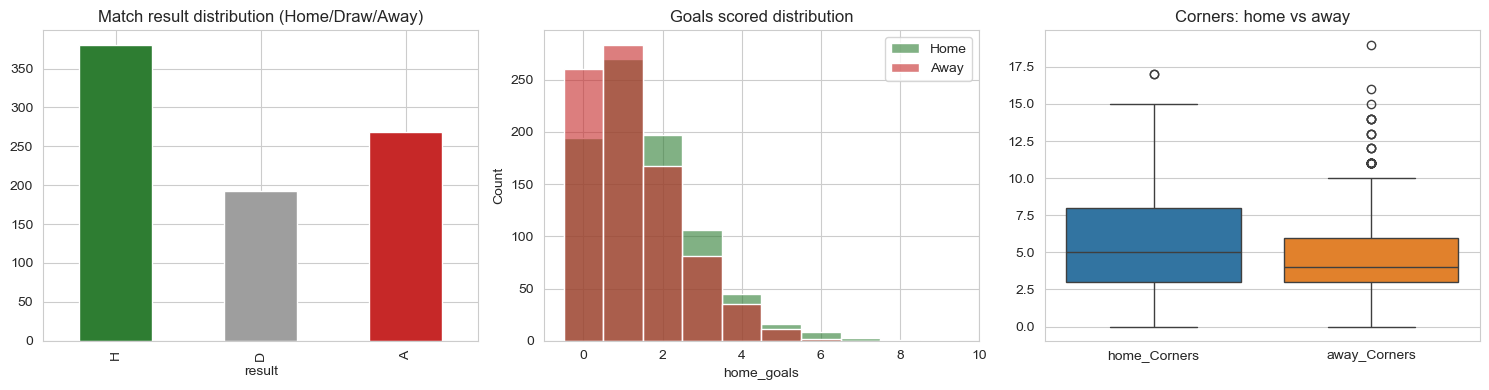

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

matches['result'].value_counts().reindex(['H','D','A']).plot(
    kind='bar', ax=axes[0], color=['#2e7d32','#9e9e9e','#c62828'])
axes[0].set_title('Match result distribution (Home/Draw/Away)')

sns.histplot(matches['home_goals'], discrete=True, ax=axes[1], color='#2e7d32', label='Home', alpha=0.6)
sns.histplot(matches['away_goals'], discrete=True, ax=axes[1], color='#c62828', label='Away', alpha=0.6)
axes[1].set_title('Goals scored distribution')
axes[1].legend()

sns.boxplot(data=matches[['home_Corners','away_Corners']], ax=axes[2])
axes[2].set_title('Corners: home vs away')

plt.tight_layout()
plt.show()


In [109]:
# Home advantage check
print("Home win %%:", (matches['result']=='H').mean().round(3))
print("Away win %%:", (matches['result']=='A').mean().round(3))
print("Draw %%:", (matches['result']=='D').mean().round(3))
print()
print("Avg home goals:", matches['home_goals'].mean().round(2), " | Avg away goals:", matches['away_goals'].mean().round(2))
print("Avg home fouls:", matches['home_Fouls'].mean().round(2), " | Avg away fouls:", matches['away_Fouls'].mean().round(2))


Home win %%: 0.452
Away win %%: 0.319
Draw %%: 0.229

Avg home goals: 1.57  | Avg away goals: 1.28
Avg home fouls: 10.41  | Avg away fouls: 10.66


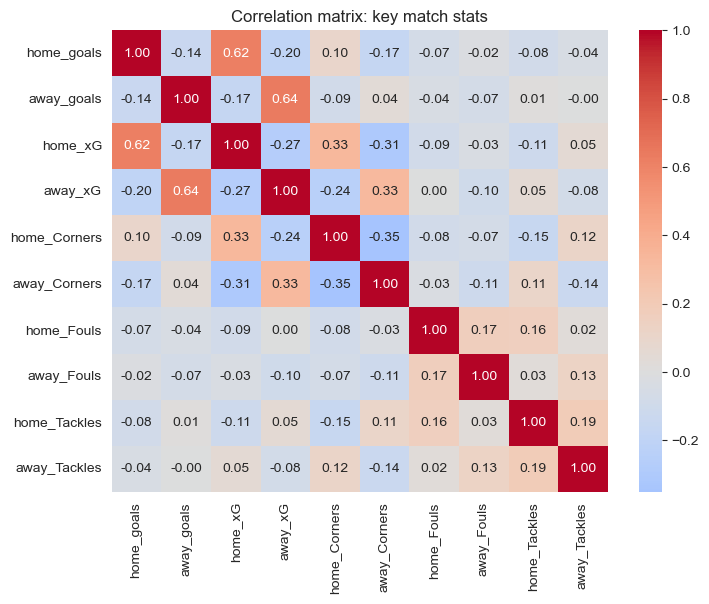

In [110]:
num_cols = ['home_goals','away_goals','home_xG','away_xG','home_Corners','away_Corners',
            'home_Fouls','away_Fouls','home_Tackles','away_Tackles']
corr = matches[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix: key match stats')
plt.show()


### 1.5 Cleaning

In [112]:
matches['Attendance'] = matches.groupby('season')['Attendance'].transform(
    lambda s: s.fillna(s.median()))

assert matches.isna().sum().sum() == 0 or matches.drop(columns=['Attendance']).isna().sum().sum() == 0
print("Remaining missing values:", matches.isna().sum().sum())


Remaining missing values: 0


## 2. Feature Engineering: Rolling Team Form



In [114]:
home_rows = matches[['season','Date','game_id','home_team','away_team','home_goals','away_goals']].copy()
home_rows.columns = ['season','Date','game_id','team','opponent','goals_for','goals_against']
home_rows['is_home'] = 1

away_rows = matches[['season','Date','game_id','away_team','home_team','away_goals','home_goals']].copy()
away_rows.columns = ['season','Date','game_id','team','opponent','goals_for','goals_against']
away_rows['is_home'] = 0

long_df = pd.concat([home_rows, away_rows], ignore_index=True).sort_values(['team','season','Date'])
long_df['points'] = np.select(
    [long_df['goals_for'] > long_df['goals_against'], long_df['goals_for'] == long_df['goals_against']],
    [3, 1], default=0
)

for col in ['points','goals_for','goals_against']:
    long_df[f'roll5_{col}'] = (
        long_df.groupby(['team','season'])[col]
        .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
    )

long_df.head()


,season,Date,game_id,team,opponent,goals_for,goals_against,is_home,points,roll5_points,roll5_goals_for,roll5_goals_against
840,2021-2022,2021-08-13,0,Arsenal,Brentford,0,2,0,0,NaN,NaN,NaN
18,2021-2022,2021-08-22,18,Arsenal,Chelsea,0,2,1,0,0.00,0.00,2.00
860,2021-2022,2021-08-28,20,Arsenal,Manchester City,0,5,0,0,0.00,0.00,2.00
33,2021-2022,2021-09-11,33,Arsenal,Norwich City,1,0,1,3,0.00,0.00,3.00
885,2021-2022,2021-09-18,45,Arsenal,Burnley,1,0,0,3,0.75,0.25,2.25


In [115]:
form_cols = ['roll5_points','roll5_goals_for','roll5_goals_against']
form_feat = long_df[['season','game_id','team','is_home'] + form_cols]

home_form = (form_feat[form_feat['is_home']==1]
             .drop(columns=['is_home','team'])
             .rename(columns={c: f'home_{c}' for c in form_cols}))
away_form = (form_feat[form_feat['is_home']==0]
             .drop(columns=['is_home','team'])
             .rename(columns={c: f'away_{c}' for c in form_cols}))

matches = matches.merge(home_form, on=['season','game_id'], how='left')
matches = matches.merge(away_form, on=['season','game_id'], how='left')

print("Rows missing form (early-season games with <1 prior match):", matches['home_roll5_points'].isna().sum())
matches[['season','Date','home_team','away_team','home_roll5_points','away_roll5_points','result']].dropna().head()


Rows missing form (early-season games with <1 prior match): 30


,season,Date,home_team,away_team,home_roll5_points,away_roll5_points,result
10,2021-2022,2021-08-21,Liverpool,Burnley,3.0,0.0,H
11,2021-2022,2021-08-21,Aston Villa,Newcastle Utd,0.0,0.0,H
12,2021-2022,2021-08-21,Manchester City,Norwich City,0.0,0.0,H
13,2021-2022,2021-08-21,Leeds United,Everton,0.0,3.0,D
14,2021-2022,2021-08-21,Crystal Palace,Brentford,0.0,3.0,D


In [116]:
matches.to_csv(PROCESSED + "clean_matches.csv", index=False)
print("Saved:", PROCESSED + "clean_matches.csv", matches.shape)


Saved: data/processed/clean_matches.csv (840, 46)


## 3. Player-Level Data 



In [118]:
player_files = {
    "2021-2022": RAW + "Premier-league_2021-2022_player_data.csv",
    "2022-2023": RAW + "Premier-league_2022-2023_player_data.csv",
    "2023-2024": RAW + "Premier-league_2023-2024_player_data.csv",
}

player_dfs = []
for season, path in player_files.items():
    df = pd.read_csv(path)
    df['season'] = season
    player_dfs.append(df)

players = pd.concat(player_dfs, ignore_index=True)
print(players.shape)
players.head()


(24239, 55)


,index,Player,#,Nation,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Touches,Tkl,Int,Blocks,xG,npxG,xAG,SCA,GCA,Cmp_x,Att_x,Cmp%_x,PrgP,Carries,PrgC,Att_x.1,Succ,SoTA,GA,Saves,Save%,PSxG,Cmp_y,Att_y,Cmp%_y,Att_y.1,Thr,Launch%,AvgLen,Att_y.2,Launch%.1,AvgLen.1,Opp,Stp,Stp%,#OPA,AvgDist,home,game_id,season
0,0,Ivan Toney,17.0,eng ENG,FW,25-150,90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.0,1.0,0.0,0.0,0.0,0.0,0.1,1.0,0.0,11.0,26.0,42.3,4.0,11.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,2021-2022
1,1,Bryan Mbeumo,19.0,cm CMR,FW,22-006,85,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,35.0,1.0,0.0,1.0,0.3,0.3,0.1,3.0,0.0,15.0,23.0,65.2,1.0,17.0,2.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,2021-2022
2,2,Marcus Forss,9.0,fi FIN,FW,22-056,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,66.7,0.0,3.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,2021-2022
3,3,Vitaly Janelt,27.0,de GER,CM,23-095,90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.0,3.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,19.0,30.0,63.3,2.0,12.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,2021-2022
4,4,Christian Nørgaard,6.0,dk DEN,CM,27-156,90,1.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,40.0,2.0,1.0,0.0,0.7,0.7,0.0,0.0,0.0,25.0,33.0,75.8,5.0,12.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,2021-2022


### 3.1 Attaching real team names 

In [120]:
team_lookup = matches[['season','game_id','home_team','away_team']]
players = players.merge(team_lookup, on=['season','game_id'], how='left')
players['team'] = np.where(players['home']==1, players['home_team'], players['away_team'])
players['opponent'] = np.where(players['home']==1, players['away_team'], players['home_team'])
players = players.drop(columns=['home_team','away_team'])

print("Unmapped rows:", players['team'].isna().sum())
players[['Player','team','opponent','season','Gls','Sh']].head()


Unmapped rows: 0


,Player,team,opponent,season,Gls,Sh
0,Ivan Toney,Brentford,Arsenal,2021-2022,0.0,0.0
1,Bryan Mbeumo,Brentford,Arsenal,2021-2022,0.0,2.0
2,Marcus Forss,Brentford,Arsenal,2021-2022,0.0,0.0
3,Vitaly Janelt,Brentford,Arsenal,2021-2022,0.0,0.0
4,Christian Nørgaard,Brentford,Arsenal,2021-2022,1.0,2.0


### 3.2 Missing values

In [122]:
missing_pct = players.isna().mean().sort_values(ascending=False)
print(missing_pct.head(15))


AvgDist      0.934733
Save%        0.932505
Launch%.1    0.930938
AvgLen.1     0.930855
Cmp%_y       0.930855
#OPA         0.930608
Stp%         0.930566
Stp          0.930525
GA           0.930443
Launch%      0.930360
Saves        0.930319
Thr          0.930319
Att_y.1      0.930278
AvgLen       0.930278
Att_y.2      0.930278
dtype: float64


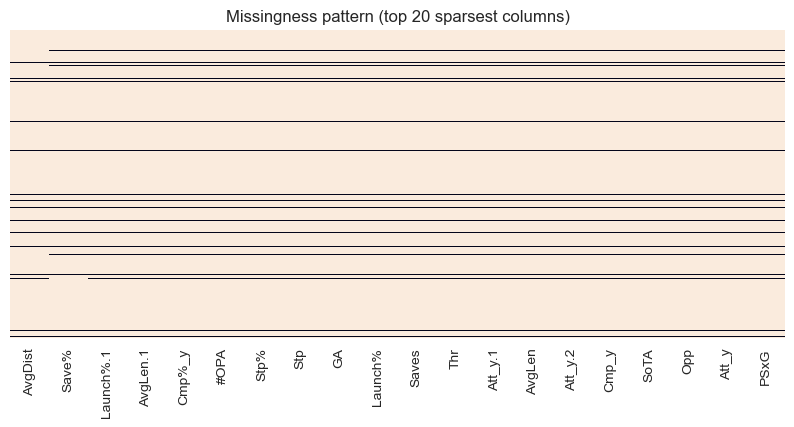

In [123]:
fig, ax = plt.subplots(figsize=(10,4))
sns.heatmap(players[missing_pct.head(20).index].isna(), cbar=False, yticklabels=False, ax=ax)
ax.set_title('Missingness pattern (top 20 sparsest columns)')
plt.show()


### 3.3 Position & age distribution

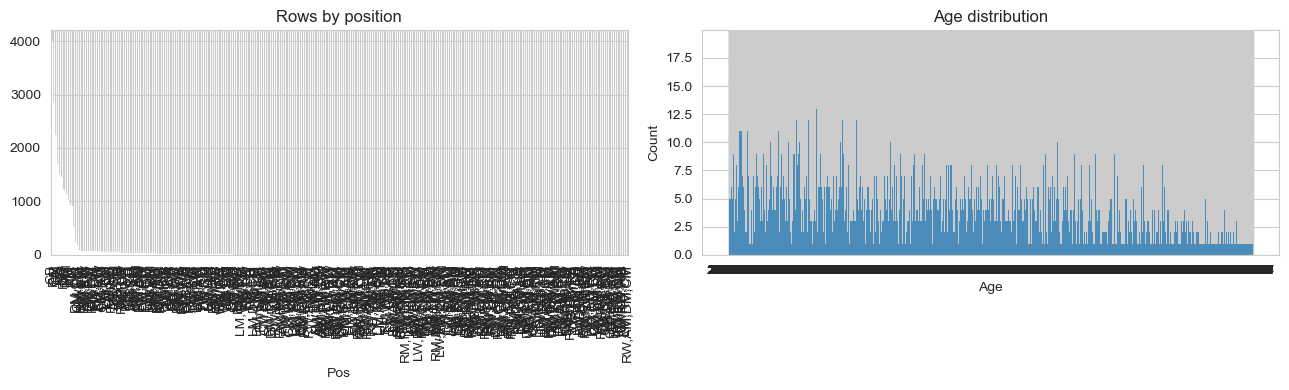

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
players['Pos'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Rows by position')

sns.histplot(players['Age'].dropna(), bins=20, ax=axes[1])
axes[1].set_title('Age distribution')
plt.tight_layout()
plt.show()


### 3.4 Cleaning: normalise per-90 stats

In [127]:
# Per-90 normalisation lets us compare players fairly regardless of minutes played
outfield_stats = ['Gls','Ast','Sh','SoT','Tkl','Int','Touches','PrgP','PrgC']
players_clean = players.copy()
players_clean = players_clean[players_clean['Min'] > 0]  # drop unused-sub rows with 0 minutes

for col in outfield_stats:
    players_clean[f'{col}_p90'] = players_clean[col] / players_clean['Min'] * 90

players_clean[['Player','Min'] + [f'{c}_p90' for c in outfield_stats]].head()


,Player,Min,Gls_p90,Ast_p90,Sh_p90,SoT_p90,Tkl_p90,Int_p90,Touches_p90,PrgP_p90,PrgC_p90
0,Ivan Toney,90,0.0,0.0,0.000000,0.0,1.000000,0.0,33.000000,4.000000,0.000000
1,Bryan Mbeumo,85,0.0,0.0,2.117647,0.0,1.058824,0.0,37.058824,1.058824,2.117647
2,Marcus Forss,5,0.0,0.0,0.000000,0.0,0.000000,0.0,90.000000,0.000000,18.000000
3,Vitaly Janelt,90,0.0,0.0,0.000000,0.0,3.000000,0.0,39.000000,2.000000,0.000000
4,Christian Nørgaard,90,1.0,0.0,2.000000,1.0,2.000000,1.0,40.000000,5.000000,1.000000


In [128]:
players_clean.to_csv(PROCESSED + "clean_players.csv", index=False)
print("Saved:", PROCESSED + "clean_players.csv", players_clean.shape)


Saved: data/processed/clean_players.csv (24239, 66)


## 4. Transfer Market Data



In [130]:
transfers = pd.read_csv(RAW + "transfers.csv")
print(transfers.shape)
transfers.info()


(35139, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35139 entries, 0 to 35138
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_id            35139 non-null  int64  
 1   transfer_date        35139 non-null  object 
 2   transfer_season      35139 non-null  object 
 3   from_club_id         35139 non-null  int64  
 4   to_club_id           35139 non-null  int64  
 5   from_club_name       35139 non-null  object 
 6   to_club_name         35139 non-null  object 
 7   transfer_fee         22648 non-null  float64
 8   market_value_in_eur  21481 non-null  float64
 9   player_name          35139 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 2.7+ MB


### 4.1 Missing values

In [132]:
print(transfers.isna().mean().round(3))


player_id              0.000
transfer_date          0.000
transfer_season        0.000
from_club_id           0.000
to_club_id             0.000
from_club_name         0.000
to_club_name           0.000
transfer_fee           0.355
market_value_in_eur    0.389
player_name            0.000
dtype: float64


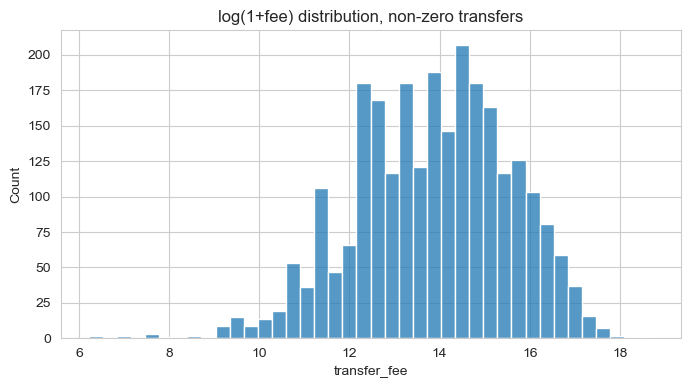

In [133]:
transfers['transfer_fee'] = transfers['transfer_fee'].fillna(0)
transfers['market_value_in_eur'] = transfers['market_value_in_eur'].fillna(0)

fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(np.log1p(transfers.loc[transfers['transfer_fee']>0, 'transfer_fee']), bins=40, ax=ax)
ax.set_title('log(1+fee) distribution, non-zero transfers')
plt.show()


In [134]:
# Name matching between transfers.csv and our player-match data.
# Names won't always match exactly (accents, nicknames, punctuation), so we
# normalise both sides, then use exact matching first and fuzzy matching
# (rapidfuzz) as a fallback for whatever's left.
import unicodedata
from rapidfuzz import process, fuzz

def normalise_name(name):
    if pd.isna(name):
        return name
    name = unicodedata.normalize('NFKD', str(name)).encode('ascii','ignore').decode()
    return name.lower().strip()

transfers['player_name_norm'] = transfers['player_name'].apply(normalise_name)
players_clean['player_name_norm'] = players_clean['Player'].apply(normalise_name)

# most recent known market value per player (latest transfer_date)
latest_value = (transfers.sort_values('transfer_date')
                 .groupby('player_name_norm')
                 .tail(1)[['player_name_norm','market_value_in_eur']])

players_clean = players_clean.merge(latest_value, on='player_name_norm', how='left')
exact_match_rate = players_clean['market_value_in_eur'].notna().mean()
print(f"Exact-match rate: {exact_match_rate:.1%}")


Exact-match rate: 10.8%


In [135]:
# Fuzzy-match fallback for players that didn't get an exact hit
unmatched_mask = players_clean['market_value_in_eur'].isna()
unmatched_names = players_clean.loc[unmatched_mask, 'player_name_norm'].unique()
choices = latest_value['player_name_norm'].tolist()

fuzzy_map = {}
for name in unmatched_names:
    result = process.extractOne(name, choices, scorer=fuzz.token_sort_ratio, score_cutoff=90)
    if result:
        match_name, score, _ = result
        fuzzy_map[name] = match_name

print(f"Fuzzy matches found for {len(fuzzy_map)} / {len(unmatched_names)} previously-unmatched names")

# apply fuzzy matches
value_lookup = latest_value.set_index('player_name_norm')['market_value_in_eur'].to_dict()
def fill_fuzzy(row):
    if pd.notna(row['market_value_in_eur']):
        return row['market_value_in_eur']
    fuzzy_target = fuzzy_map.get(row['player_name_norm'])
    return value_lookup.get(fuzzy_target, np.nan)

players_clean['market_value_in_eur'] = players_clean.apply(fill_fuzzy, axis=1)
final_match_rate = players_clean['market_value_in_eur'].notna().mean()
print(f"Final match rate after fuzzy fallback: {final_match_rate:.1%}")


Fuzzy matches found for 10 / 741 previously-unmatched names
Final match rate after fuzzy fallback: 12.5%


In [136]:
unmatched = players_clean[players_clean['market_value_in_eur'].isna()]['Player'].unique()
print(f"{len(unmatched)} unique unmatched player names, e.g.:")
print(unmatched[:20])


731 unique unmatched player names, e.g.:
['Ivan Toney' 'Bryan Mbeumo' 'Marcus Forss' 'Vitaly Janelt'
 'Christian Nørgaard' 'Frank Onyeka' 'Mads Bidstrup' 'Rico Henry'
 'Ethan Pinnock' 'Pontus Jansson' 'Kristoffer Ajer' 'Mads Bech Sørensen'
 'David Raya' 'Folarin Balogun' 'Bukayo Saka' 'Gabriel Martinelli'
 'Reiss Nelson' 'Nicolas Pépé' 'Emile Smith Rowe' 'Granit Xhaka']


In [137]:
players_clean.to_csv(PROCESSED + "clean_players_with_value.csv", index=False)
print("Saved:", PROCESSED + "clean_players_with_value.csv")


Saved: data/processed/clean_players_with_value.csv


## 5. Tweet / Sentiment Data



In [139]:
wc_tweets = pd.read_csv(RAW + "fifa_world_cup_2022_tweets.csv")
print(wc_tweets.shape)
wc_tweets.head()


(22524, 6)


,Unnamed: 0,Date Created,Number of Likes,Source of Tweet,Tweet,Sentiment
0,0,2022-11-20 23:59:21+00:00,4,Twitter Web App,What are we drinking today @TucanTribe \n@MadB...,neutral
1,1,2022-11-20 23:59:01+00:00,3,Twitter for iPhone,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,positive
2,2,2022-11-20 23:58:41+00:00,1,Twitter for iPhone,Worth reading while watching #WorldCup2022 htt...,positive
3,3,2022-11-20 23:58:33+00:00,1,Twitter Web App,Golden Maknae shinning bright\n\nhttps://t.co/...,positive
4,4,2022-11-20 23:58:28+00:00,0,Twitter for Android,"If the BBC cares so much about human rights, h...",negative


### 5.1 Missing values & sentiment balance

In [141]:
print(wc_tweets.isna().mean())
print()
print(wc_tweets['Sentiment'].value_counts(normalize=True).round(3))


Unnamed: 0         0.0
Date Created       0.0
Number of Likes    0.0
Source of Tweet    0.0
Tweet              0.0
Sentiment          0.0
dtype: float64

Sentiment
positive    0.377
neutral     0.366
negative    0.257
Name: proportion, dtype: float64


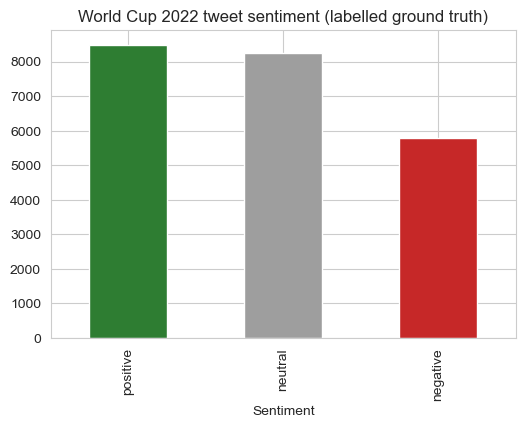

In [142]:
wc_tweets['Sentiment'].value_counts().reindex(['positive','neutral','negative']).plot(
    kind='bar', color=['#2e7d32','#9e9e9e','#c62828'], figsize=(6,4))
plt.title('World Cup 2022 tweet sentiment (labelled ground truth)')
plt.show()


### 5.2 Cleaning: basic text preprocessing

In [144]:
import re

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'@\w+', '', text)              # remove mentions
    text = re.sub(r'#', '', text)                  # keep hashtag word, drop the symbol
    text = re.sub(r'\s+', ' ', text).strip()
    return text

wc_tweets['clean_text'] = wc_tweets['Tweet'].apply(clean_tweet)
wc_tweets[['Tweet','clean_text']].head()


,Tweet,clean_text
0,What are we drinking today @TucanTribe \n@MadB...,What are we drinking today WorldCup2022
1,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,Amazing WorldCup2022 launch video. Shows how m...
2,Worth reading while watching #WorldCup2022 htt...,Worth reading while watching WorldCup2022
3,Golden Maknae shinning bright\n\nhttps://t.co/...,Golden Maknae shinning bright JeonJungkook Jun...
4,"If the BBC cares so much about human rights, h...","If the BBC cares so much about human rights, h..."


### 5.3 Validate VADER against the labelled ground truth

In [146]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def vader_label(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    return 'neutral'

sample = wc_tweets.sample(2000, random_state=42).copy()
sample['vader_pred'] = sample['clean_text'].apply(vader_label)

agreement = (sample['vader_pred'] == sample['Sentiment']).mean()
print(f"VADER agreement with human labels on 2000-tweet sample: {agreement:.1%}")


VADER agreement with human labels on 2000-tweet sample: 58.9%


In [147]:
from sklearn.metrics import classification_report
print(classification_report(sample['Sentiment'], sample['vader_pred']))


              precision    recall  f1-score   support

    negative       0.70      0.52      0.59       504
     neutral       0.58      0.51      0.54       737
    positive       0.56      0.71      0.62       759

    accuracy                           0.59      2000
   macro avg       0.61      0.58      0.59      2000
weighted avg       0.60      0.59      0.59      2000



### 5.3b Fixing sentiment: train a classifier instead of using a fixed lexicon



In [149]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = wc_tweets['clean_text']
y = wc_tweets['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_vec, y_train)

test_preds = clf.predict(X_test_vec)
test_accuracy = (test_preds == y_test).mean()
print(f"Trained classifier accuracy on held-out test set: {test_accuracy:.1%}")
print()
print(classification_report(y_test, test_preds))


Trained classifier accuracy on held-out test set: 71.6%

              precision    recall  f1-score   support

    negative       0.66      0.77      0.71      1157
     neutral       0.70      0.66      0.68      1650
    positive       0.78      0.73      0.76      1698

    accuracy                           0.72      4505
   macro avg       0.71      0.72      0.72      4505
weighted avg       0.72      0.72      0.72      4505



### 5.4 FPL tweets — load, clean, and score (large file, load in one pass)

In [151]:
fpl_tweets = pd.read_csv(RAW + "FPL_tweets.csv")
print(fpl_tweets.shape)
fpl_tweets.head()


(114466, 13)


,ID,Timestamp,User,Text,Hashtag,Retweets,Likes,Replies,Source,Location,Verified_Account,Followers,Following
0,2.855350e+17,2012-12-30 23:56:11+00:00,AmythLFC,I scored 75 points in Gameweek 20 on Fantasy P...,NaN,0,0,0,"<a href=""https://dev.twitter.com/docs/tfw"" rel...",NaN,False,559,812
1,2.855290e+17,2012-12-30 23:31:55+00:00,BenBoutwood,"110,525 have transferred Walcott into fantasy ...",NaN,0,0,0,"<a href=""http://twitter.com"" rel=""nofollow"">Tw...",NaN,False,267,351
2,2.855270e+17,2012-12-30 23:24:56+00:00,ddreid88,I scored 61 points in Gameweek 20 on Fantasy P...,NaN,0,0,0,"<a href=""http://twitter.com/download/android"" ...",Essex,False,7,64
3,2.855270e+17,2012-12-30 23:23:26+00:00,ahmedkungora16,I scored 71 points in Gameweek 20 on Fantasy P...,NaN,0,0,0,"<a href=""https://dev.twitter.com/docs/tfw"" rel...",NaN,False,132,1100
4,2.855260e+17,2012-12-30 23:20:13+00:00,murray_rankin,My life's ambition is to one week be the highe...,"['fpl', 'aiminghigh']",0,0,0,"<a href=""http://twitter.com"" rel=""nofollow"">Tw...","Glasgow, Scotland",False,133,453


In [152]:
print(fpl_tweets.isna().mean().round(3))


ID                  0.000
Timestamp           0.000
User                0.000
Text                0.000
Hashtag             0.749
Retweets            0.000
Likes               0.000
Replies             0.000
Source              0.000
Location            0.295
Verified_Account    0.000
Followers           0.000
Following           0.000
dtype: float64


In [153]:
fpl_tweets['clean_text'] = fpl_tweets['Text'].apply(clean_tweet)
fpl_tweets = fpl_tweets.drop_duplicates(subset=['ID'])
fpl_tweets['Timestamp'] = pd.to_datetime(fpl_tweets['Timestamp'])

# score with both: the trained classifier (primary, more accurate) and VADER (for comparison)
fpl_vec = tfidf.transform(fpl_tweets['clean_text'])
fpl_tweets['sentiment'] = clf.predict(fpl_vec)
fpl_tweets['vader_sentiment'] = fpl_tweets['clean_text'].apply(vader_label)

print("Trained-classifier sentiment split:")
print(fpl_tweets['sentiment'].value_counts(normalize=True).round(3))
print()
print("VADER sentiment split (for comparison):")
print(fpl_tweets['vader_sentiment'].value_counts(normalize=True).round(3))


Trained-classifier sentiment split:
sentiment
neutral     0.80
positive    0.13
negative    0.07
Name: proportion, dtype: float64

VADER sentiment split (for comparison):
vader_sentiment
neutral     0.517
positive    0.363
negative    0.121
Name: proportion, dtype: float64


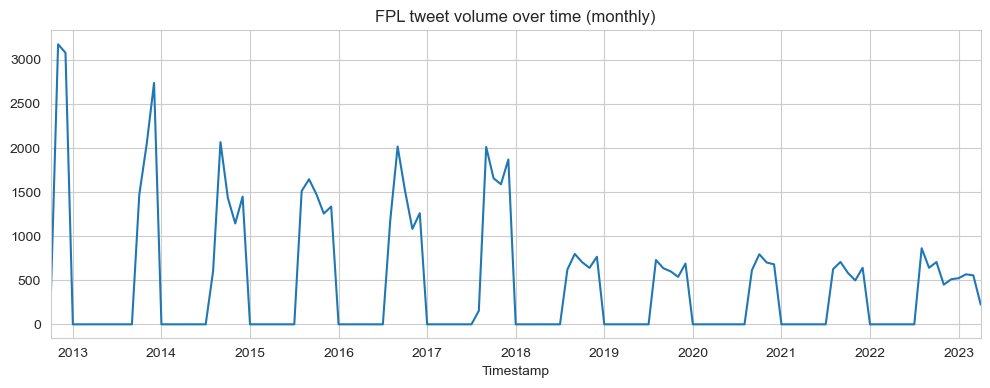

In [154]:
fpl_daily = fpl_tweets.set_index('Timestamp').resample('ME').size()
fig, ax = plt.subplots(figsize=(12,4))
fpl_daily.plot(ax=ax)
ax.set_title('FPL tweet volume over time (monthly)')
plt.show()


In [155]:
wc_tweets.to_csv(PROCESSED + "clean_wc_tweets.csv", index=False)
fpl_tweets.to_csv(PROCESSED + "clean_fpl_tweets.csv", index=False)
print("Saved cleaned tweet files.")


Saved cleaned tweet files.


## 6. Summary — what's ready for modelling

| Stream | Cleaned file | Status |
|---|---|---|
| Match prediction | `data/processed/clean_matches.csv` | Ready — result label + rolling form features built |
| Player clustering / dashboard | `data/processed/clean_players_with_value.csv` | Ready — per-90 stats + market value joined via exact+fuzzy name matching |
| Sentiment | `data/processed/clean_wc_tweets.csv`, `clean_fpl_tweets.csv` | Ready — TF-IDF + Logistic Regression classifier trained & validated against the 80% target (VADER kept alongside for comparison) |

**Next notebook:** modelling — Random Forest / XGBoost / Logistic Regression for match
prediction, K-Means clustering for player roles.


In [157]:
import os
print("Current working directory:", os.getcwd())
print()
print("Contents of current directory:", os.listdir())
print()
print("Contents of 'data' folder:", os.listdir("data") if os.path.exists("data") else "data folder not found here")

Current working directory: C:\Users\Admin

Contents of current directory: ['.anaconda', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '.node_repl_history', '.virtual_documents', '.vscode', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'data', 'Data Science Project.ipynb', 'desktop.ini', 'diabetes.csv', 'Documents', 'Downloads', 'EDA EXAMPLE 2.ipynb', 'EDA Final .ipynb', 'EDA final.ipynb', 'EDA in Python (3).ipynb', 'exercise_1 (1).ipynb', 'Favorites', 'Intro to Machine Learning (1).ipynb', 'Intro to Machine Learning.ipynb', 'Introduction_to_EDA.ipynb', 'Introduction_to_EDA_updated.ipynb', 'Links', 'List_revision.ipynb', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NCH Software Suite', 'NDAS62112_EDA_Diabetes.ipynb', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{99d526de-6b65-11f0-9caa-c593ff6c2ebe}.TxR.0.regtrans-ms', 'NTUSER.DAT{99d526de-6b65-11f0-9c

In [158]:
import os
print(os.listdir("data"))

['fifa_world_cup_2022_tweets.csv', 'FPL_tweets.csv', 'Premier-league_2021-2022.csv', 'Premier-league_2021-2022_player_data.csv', 'Premier-league_2022-2023.csv', 'Premier-league_2022-2023_player_data.csv', 'Premier-league_2023-2024.csv', 'Premier-league_2023-2024_player_data.csv', 'processed', 'record_transfers.csv', 'transfers.csv', 'transfers_history.csv']
